# Проверка модели на 200 новостях

Ноутбук обучает модель на файле `knowledge_base_200 news.csv` и проверяет её на
выборке `test base_16.csv`, где содержится по 4 новости для каждой категории.

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

TRAIN_FILE = "knowledge_base_200 news.csv"
TEST_FILE = "test base_16.csv"


def normalize_text(text):
    return " ".join(str(text).lower().replace("\xa0", " ").split())


def build_pipeline():
    return Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    max_features=5000,
                    min_df=2,
                    max_df=0.95,
                    ngram_range=(1, 2),
                ),
            ),
            (
                "model",
                KNeighborsClassifier(
                    n_neighbors=5,
                    metric="cosine",
                    weights="distance",
                ),
            ),
        ]
    )

In [2]:
train_df = pd.read_csv(TRAIN_FILE)
test_df = pd.read_csv(TEST_FILE)

train_df["text_clean"] = train_df["text"].apply(normalize_text)
test_df["text_clean"] = test_df["text"].apply(normalize_text)

print("ОБУЧАЮЩАЯ ВЫБОРКА")
print(train_df["category"].value_counts().sort_index())
print(f"Размер: {train_df.shape}")

print("\nПРОВЕРЯЮЩАЯ ВЫБОРКА")
print(test_df["category"].value_counts().sort_index())
print(f"Размер: {test_df.shape}")

ОБУЧАЮЩАЯ ВЫБОРКА
category
culture      50
economics    50
science      50
sport        50
Name: count, dtype: int64
Размер: (200, 5)

ПРОВЕРЯЮЩАЯ ВЫБОРКА
category
culture      4
economics    4
science      4
sport        4
Name: count, dtype: int64
Размер: (16, 5)


In [3]:
pipeline = build_pipeline()
pipeline.fit(train_df["text_clean"], train_df["category"])

predictions = pipeline.predict(test_df["text_clean"])

results_df = test_df[["title", "category", "url"]].copy()
results_df["predicted_category"] = predictions
results_df["is_correct"] = results_df["category"] == results_df["predicted_category"]

accuracy = accuracy_score(test_df["category"], predictions)

print(f"Точность модели: {accuracy:.4f}")
print("\nДЕТАЛЬНЫЙ ОТЧЁТ:")
print(classification_report(test_df["category"], predictions))

results_df

Точность модели: 0.9375

ДЕТАЛЬНЫЙ ОТЧЁТ:
              precision    recall  f1-score   support

     culture       1.00      1.00      1.00         4
   economics       0.80      1.00      0.89         4
     science       1.00      1.00      1.00         4
       sport       1.00      0.75      0.86         4

    accuracy                           0.94        16
   macro avg       0.95      0.94      0.94        16
weighted avg       0.95      0.94      0.94        16



,title,category,url,predicted_category,is_correct
0,«Аэрофлот» проведет акцию для ветеранов в чест...,economics,https://lenta.ru/news/2026/04/20/aeroflot-prov...,economics,True
1,Названо условие ослабления курса рубля по отно...,economics,https://lenta.ru/news/2026/04/20/nazvano-uslov...,economics,True
2,Обновление Windows сломало все версии ОС,science,https://lenta.ru/news/2026/04/16/bitlocker/,science,True
3,Во Франции опровергли интерес к самому дорогом...,sport,https://lenta.ru/news/2026/04/16/vo-frantsii-o...,economics,False
4,Стали известны полуфинальные пары Лиги чемпионов,sport,https://lenta.ru/news/2026/04/16/stali-izvestn...,sport,True
5,Обвиненный в педофилии культовый рэпер умер в США,culture,https://lenta.ru/news/2026/04/10/obvinennyy-v-...,culture,True
6,Названа причина смерти актера из сериала «След...,culture,https://lenta.ru/news/2026/04/11/prichina-smerty/,culture,True
7,Юрий Лоза усомнился в подлинности снимков круг...,culture,https://lenta.ru/news/2026/04/11/yuriy-loza-us...,culture,True
8,Число новых ритуальных компаний России взлетело,economics,https://lenta.ru/news/2026/04/20/ritual/,economics,True
9,Оценены шансы «Атлетико» выбить «Арсенал» в по...,sport,https://lenta.ru/news/2026/04/16/otseneny-shan...,sport,True


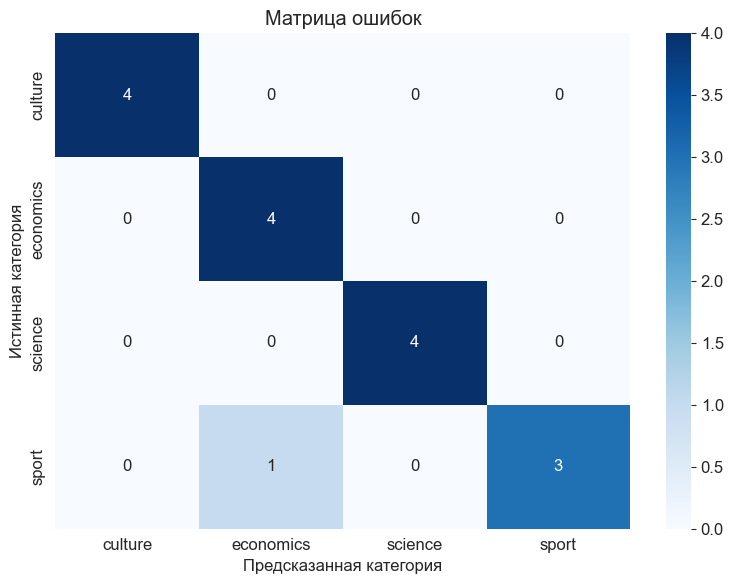

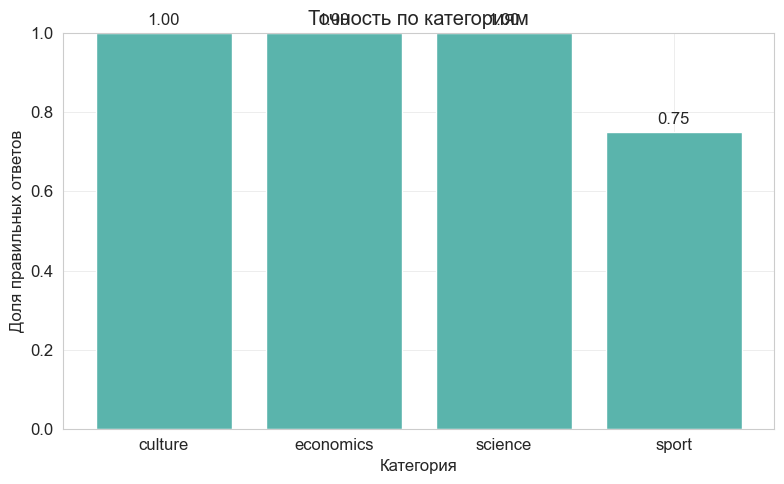

In [4]:
labels = sorted(test_df["category"].unique())
matrix = confusion_matrix(test_df["category"], predictions, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.title("Матрица ошибок")
plt.xlabel("Предсказанная категория")
plt.ylabel("Истинная категория")
plt.tight_layout()
plt.show()

category_accuracy = (
    results_df.groupby("category")["is_correct"]
    .mean()
    .sort_index()
    .reset_index(name="accuracy")
)

plt.figure(figsize=(8, 5))
bars = plt.bar(category_accuracy["category"], category_accuracy["accuracy"], color="#5ab4ac")
plt.title("Точность по категориям")
plt.xlabel("Категория")
plt.ylabel("Доля правильных ответов")
plt.ylim(0, 1)

for bar, value in zip(bars, category_accuracy["accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.2f}",
        ha="center",
    )

plt.tight_layout()
plt.show()